Data sources: [Statistics Canada](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1310083701) <i>("download entire table")</i><br>
[List of Canadian provinces and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_Canadian_provinces_and_territories_by_life_expectancy) / [Продолжительность жизни в провинциях и территориях Канады](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_провинциях_и_территориях_Канады)

In [7]:
import pandas as pd
import math
import re
from collections import namedtuple
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import sys
sys.path.append("..")
import mal_moduls_private.mal_total as mal

In [8]:
pd.options.display.min_rows=8
pd.options.display.max_rows=100

In [9]:
LANG = 'en'
YEAR_SELECTED = 2019
REGION_1 = 'Ontario'
REGION_2 = 'Quebec'
REGION_3 = 'British Columbia'
WRITE_TABLES = True
DESTINATION_CHART = 'show'  # to where table code should be placed: 'file', 'show'

In [10]:
# load data
df = pd.read_csv('data/Canada-1year-2024.zip', compression='zip',
                 usecols = ['REF_DATE', 'GEO', 'Age group', 'Sex', 'Element', 'VALUE'])

df= df.loc[(df['REF_DATE'] == YEAR_SELECTED) & (df['Element'] == 'Number of survivors at age x (lx)')]

df.head(2)

,REF_DATE,GEO,Age group,Sex,Element,VALUE
1168830,2019,Canada,0 years,Both sexes,Number of survivors at age x (lx),100000.0
1168839,2019,Canada,0 years,Males,Number of survivors at age x (lx),100000.0


In [11]:
df = df.drop(columns=['REF_DATE', 'Element']) \
       .rename(columns={'GEO': 'region',
                        'Age group': 'age',
                        'Sex': 'sex',
                        'VALUE': 'value'})

df['age'] = df['age'].replace({'110 years and over' : '110', '1 year' : '1'}) \
                     .map(lambda st: st.replace(' years', ''))  \
                     .astype(int)

# df = df.astype({'age': int, 'value': int})

df

,region,age,sex,value
1168830,Canada,0,Both sexes,100000.0
1168839,Canada,0,Males,100000.0
1168848,Canada,0,Females,100000.0
1168857,Canada,1,Both sexes,99562.0
...,...,...,...,...
1198764,British Columbia,109,Females,50.0
1198773,British Columbia,110,Both sexes,17.0
1198782,British Columbia,110,Males,6.0
1198791,British Columbia,110,Females,25.0


In [12]:
# check types of values in columns, just in case
df.dtypes

region     object
age         int32
sex        object
value     float64
dtype: object

<br>

In [14]:
df.head(4)

,region,age,sex,value
1168830,Canada,0,Both sexes,100000.0
1168839,Canada,0,Males,100000.0
1168848,Canada,0,Females,100000.0
1168857,Canada,1,Both sexes,99562.0


In [15]:
def get_data_for_single_region(df, region, suffix_for_columns=''):
    df = df.loc[df['region'] == region] \
           .drop(columns=['region'])

    df = pd.pivot_table(df, values='value', index='age', columns='sex')
    df = df.astype(int)

    df.rename(columns={'Both sexes':'total', 'Males':'males', 'Females':'females'}, inplace=True)
    df = df[['males', 'total', 'females']]
    df['fΔm'] = df['females'] - df['males']     # No requirement for rounding since numbers are integers
    df['ratio_fm'] = (df['females'] / df['males']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]
    
    return df


df = pd.concat([
        get_data_for_single_region(df, 'Canada'),
        get_data_for_single_region(df, REGION_1, '_r1'),
        get_data_for_single_region(df, REGION_2, '_r2'),
        get_data_for_single_region(df, REGION_3, '_r3')], axis='columns')

df.loc[[0, 1, 5]+list(range(100, 111))]

,males,total,females,fΔm,ratio_fm,males_r1,total_r1,females_r1,fΔm_r1,ratio_fm_r1,males_r2,total_r2,females_r2,fΔm_r2,ratio_fm_r2,males_r3,total_r3,females_r3,fΔm_r3,ratio_fm_r3
age,,,,,,,,,,,,,,,,,,,,
0,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00,100000,100000,100000,0,1.00
1,99512,99562,99614,102,1.00,99524,99553,99583,59,1.00,99510,99594,99682,172,1.00,99633,99670,99710,77,1.00
5,99443,99497,99554,111,1.00,99465,99494,99526,61,1.00,99443,99536,99636,193,1.00,99582,99616,99654,72,1.00
100,1796,3435,4828,3032,2.69,1900,3618,5090,3190,2.68,1802,3535,4874,3072,2.70,2216,3757,5155,2939,2.33
101,1164,2362,3366,2202,2.89,1229,2482,3540,2311,2.88,1169,2443,3412,2243,2.92,1455,2581,3582,2127,2.46
102,728,1571,2267,1539,3.11,767,1645,2376,1609,3.10,731,1634,2309,1578,3.16,921,1713,2401,1480,2.61
103,439,1010,1472,1033,3.35,461,1053,1537,1076,3.33,442,1057,1508,1066,3.41,563,1097,1551,988,2.75
104,255,626,922,667,3.62,267,650,957,690,3.58,257,660,950,693,3.70,331,678,964,633,2.91
105,143,375,556,413,3.89,149,386,573,424,3.85,144,398,577,433,4.01,188,403,577,389,3.07


In [16]:
# alternative look at the result
df.loc[[0, 1, 5]+list(range(100, 111)), ['males', 'males_r1', 'males_r2', 'males_r3', 'females', 'females_r1', 'females_r2', 'females_r3']]

,males,males_r1,males_r2,males_r3,females,females_r1,females_r2,females_r3
age,,,,,,,,
0,100000,100000,100000,100000,100000,100000,100000,100000
1,99512,99524,99510,99633,99614,99583,99682,99710
5,99443,99465,99443,99582,99554,99526,99636,99654
100,1796,1900,1802,2216,4828,5090,4874,5155
101,1164,1229,1169,1455,3366,3540,3412,3582
102,728,767,731,921,2267,2376,2309,2401
103,439,461,442,563,1472,1537,1508,1551
104,255,267,257,331,922,957,950,964
105,143,149,144,188,556,573,577,577


In [17]:
# df.loc[[0, 1, 5]+list(range(100, 111)), ['total', 'total_r1', 'total_r2']]

<br>
<br>

In [19]:
# Code in this cell generates an extended table about percentage surviving in the country as a whole and in the selected regions
# (by default, these are Ontario and Quebec)

def create_table_extended(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x/1000:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in [1] + list(range(5, 111, 5)):
        ser = df.iloc[i]
        age = ser.name

        if age < 100:
            prec = 1
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;padding-right:3ex;"| {transform_value(ser.loc['fΔm'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f} ' + \
                f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_r1'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_r1'], prec=prec)} ' + \
                f'||style="color:darkgray;padding-right:3ex;"| {transform_value(ser.loc['fΔm_r1'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_r1']:0.2f} ' + \
                f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_r2'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_r2'], prec=prec)} ' + \
                f'||style="color:darkgray;padding-right:3ex;"| {transform_value(ser.loc['fΔm_r2'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_r2']:0.2f}'
            if lang == 'en':
                st += ' ' + \
                    f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['males_r3'], prec=prec)} ' + \
                    f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females_r3'], prec=prec)} ' + \
                    f'||style="color:darkgray;padding-right:3ex;"| {transform_value(ser.loc['fΔm_r3'], prec=prec)} ' + \
                    f'||style="color:darkgray;"| {ser.loc['ratio_fm_r3']:0.2f}'
        else:
            prec = 3
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:1ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {transform_value(ser.loc['fΔm'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f} ' + \
                f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_r1'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_r1'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {transform_value(ser.loc['fΔm_r1'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_r1']:0.2f} ' + \
                f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_r2'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_r2'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {transform_value(ser.loc['fΔm_r2'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm_r2']:0.2f}'
            if lang == 'en':
                st += ' ' + \
                    f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['males_r3'], prec=prec)} ' + \
                    f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females_r3'], prec=prec)} ' + \
                    f'||style="color:darkgray;"| {transform_value(ser.loc['fΔm_r3'], prec=prec)} ' + \
                    f'||style="color:darkgray;"| {ser.loc['ratio_fm_r3']:0.2f}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'
    return st
        

if WRITE_TABLES:
    table_code = create_table_extended(df, file_header='Perc_surviving_header_country_and_2_regions -ru.txt', lang='ru')
    with open(f"output/Table code for percentage surviving extended -{YEAR_SELECTED} -ru.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)
    
    table_code = create_table_extended(df, file_header='Perc_surviving_header_country_and_3_regions -en.txt', lang='en')
    with open(f"output/Table code for percentage surviving extended -{YEAR_SELECTED} -en.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

<br>
<br>

In [21]:
# This function generates a simple table about percentage surviving in the country as a whole or in a single province

def create_table_region(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x/1000:0.{prec}f}"


    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in [1] + list(range(5, 111, 5)):
        ser = df.iloc[i]
        age = ser.name

        if age < 100:
            prec = 1
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;padding-right:3ex;"| {transform_value(ser.loc['fΔm'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f}'
        else:
            prec = 3
            st += '\n' + '|-\n' + \
                f'|style="padding-right:3ex;"| {age} ' + \
                f'||style="color:blue;padding-right:1ex;"| {transform_value(ser.loc['males'], prec=prec)} ' + \
                f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['females'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {transform_value(ser.loc['fΔm'], prec=prec)} ' + \
                f'||style="color:darkgray;"| {ser.loc['ratio_fm']:0.2f}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'
    return st


# generate a simple table about percentage surviving in Canada as a whole
if WRITE_TABLES:
    table_code = create_table_region(df[['males', 'total', 'females', 'fΔm', 'ratio_fm']],
                                     file_header='Perc_surviving_header -en.txt', lang='en')
    with open('output/Table code for percentage surviving simple -en.txt', 'w', encoding="utf-8") as fh:
        fh.write(table_code)

    table_code = create_table_region(df[['males', 'total', 'females', 'fΔm', 'ratio_fm']],
                                     file_header='Perc_surviving_header -ru.txt', lang='ru')
    with open('output/Table code for percentage surviving simple -ru.txt', 'w', encoding="utf-8") as fh:
        fh.write(table_code)

In [22]:
# generate a simple table about percentage surviving in the given provinces
if WRITE_TABLES:
    table_code = create_table_region(df[['males_r1', 'total_r1', 'females_r1', 'fΔm_r1', 'ratio_fm_r1']] \
                                       .rename(columns={'males_r1': 'males', 'total_r1': 'total', 'females_r1': 'females', 'fΔm_r1': 'fΔm', 'ratio_fm_r1': 'ratio_fm'}),
                                     file_header='Perc_surviving_header -en.txt', lang='en')
    with open(f'output/Table code for percentage surviving -{REGION_1} -en.txt', 'w', encoding="utf-8") as fh:
        fh.write(table_code)
    
    table_code = create_table_region(df[['males_r1', 'total_r1', 'females_r1', 'fΔm_r1', 'ratio_fm_r1']] \
                                       .rename(columns={'males_r1': 'males', 'total_r1': 'total', 'females_r1': 'females', 'fΔm_r1': 'fΔm', 'ratio_fm_r1': 'ratio_fm'}),
                                     file_header='Perc_surviving_header -ru.txt', lang='ru')
    with open(f'output/Table code for percentage surviving -{REGION_1} -ru.txt', 'w', encoding="utf-8") as fh:
        fh.write(table_code)



    table_code = create_table_region(df[['males_r2', 'total_r2', 'females_r2', 'fΔm_r2', 'ratio_fm_r2']] \
                                       .rename(columns={'males_r2': 'males', 'total_r2': 'total', 'females_r2': 'females', 'fΔm_r2': 'fΔm', 'ratio_fm_r2': 'ratio_fm'}),
                                     file_header='Perc_surviving_header -en.txt', lang='en')
    with open(f'output/Table code for percentage surviving -{REGION_2} -en.txt', 'w', encoding="utf-8") as fh:
        fh.write(table_code)
    
    table_code = create_table_region(df[['males_r2', 'total_r2', 'females_r2', 'fΔm_r2', 'ratio_fm_r2']] \
                                       .rename(columns={'males_r2': 'males', 'total_r2': 'total', 'females_r2': 'females', 'fΔm_r2': 'fΔm', 'ratio_fm_r2': 'ratio_fm'}),
                                     file_header='Perc_surviving_header -ru.txt', lang='ru')
    with open(f'output/Table code for percentage surviving -{REGION_2} -ru.txt', 'w', encoding="utf-8") as fh:
        fh.write(table_code)



    table_code = create_table_region(df[['males_r3', 'total_r3', 'females_r3', 'fΔm_r3', 'ratio_fm_r3']] \
                                       .rename(columns={'males_r3': 'males', 'total_r3': 'total', 'females_r3': 'females', 'fΔm_r3': 'fΔm', 'ratio_fm_r3': 'ratio_fm'}),
                                     file_header='Perc_surviving_header -en.txt', lang='en')
    with open(f'output/Table code for percentage surviving -{REGION_3} -en.txt', 'w', encoding="utf-8") as fh:
        fh.write(table_code)
    
    table_code = create_table_region(df[['males_r3', 'total_r3', 'females_r3', 'fΔm_r3', 'ratio_fm_r3']] \
                                       .rename(columns={'males_r3': 'males', 'total_r3': 'total', 'females_r3': 'females', 'fΔm_r3': 'fΔm', 'ratio_fm_r3': 'ratio_fm'}),
                                     file_header='Perc_surviving_header -ru.txt', lang='ru')
    with open(f'output/Table code for percentage surviving -{REGION_3} -ru.txt', 'w', encoding="utf-8") as fh:
        fh.write(table_code)

<br>
<br>

In [24]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'color', 'style', 'width', 'alpha'])

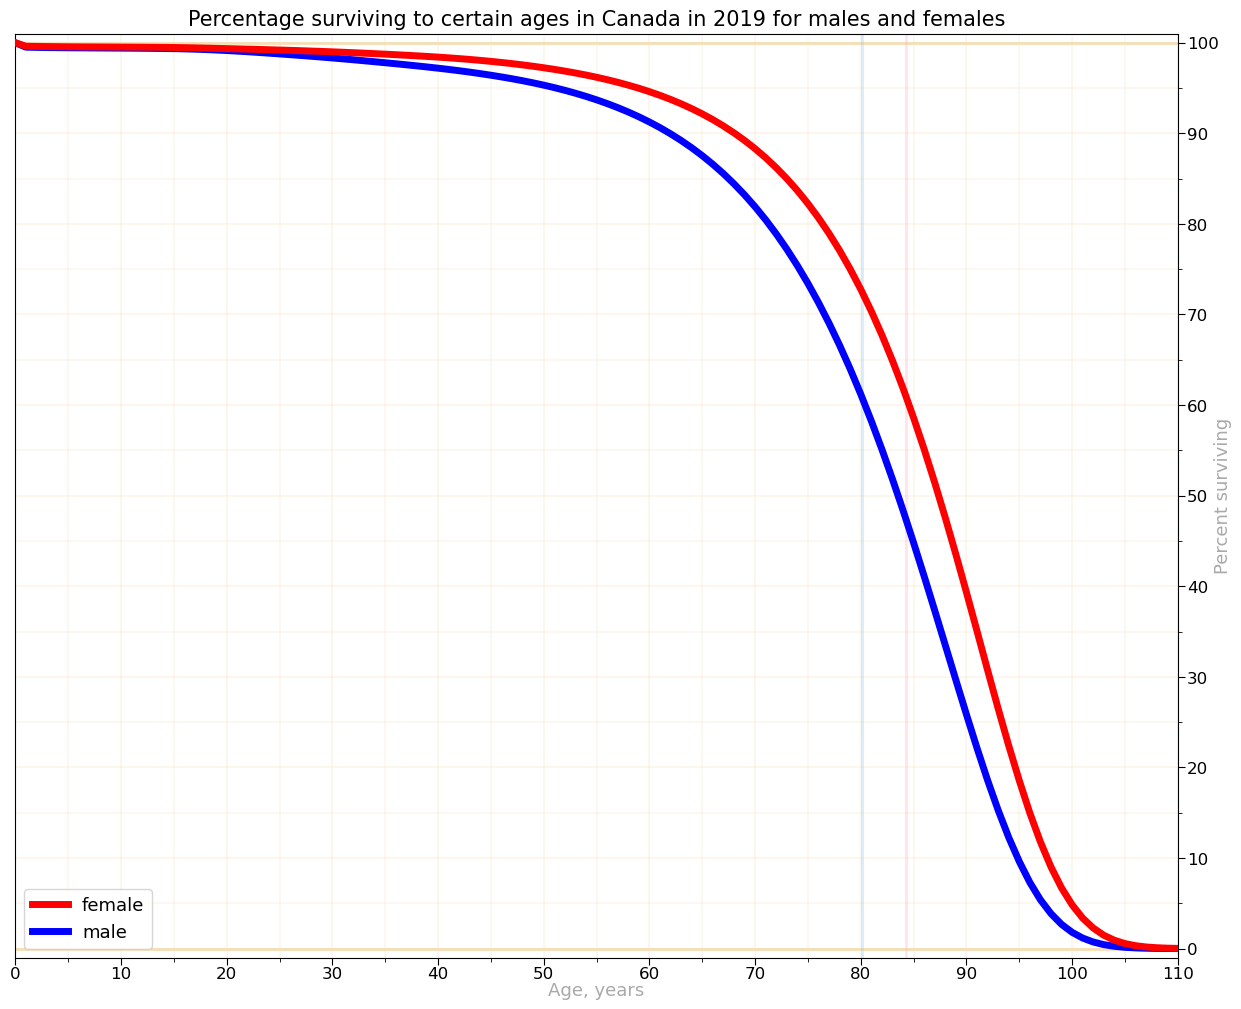

In [25]:
def create_chart(
        df, lang=LANG, dd_display='', ncol=2,
        title_en='Title of the chart', title_ru='Заголовок графика',
        le_male=None, le_female=None,
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (16, 12.5) if lang=='ru' else (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()  # show ticks only at the left side
    ax.yaxis.set_label_position("right")  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=3)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=3)  # Minor ticks are shorter
    plt.xticks(fontsize=12)  # font size for tick labels
    plt.yticks(fontsize=12)
    
    x_min = y_min = 0
    x_max = 110
    y_max = 100
    plt.xlim(0, 110)
    plt.ylim(-1, 101)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.3)

    plt.axhline(y=100, color='wheat', linewidth=2)
    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else title_en, fontsize=15)
    plt.xlabel('Возраст, годы' if lang=='ru' else 'Age, years', fontsize=13, color='darkgray', labelpad=-0.5)
    plt.ylabel('Процент выживших' if lang=='ru' else 'Percent surviving', fontsize=13, color='darkgray', labelpad=-3.5)
    # plt.ylabel('Доля выживших' if lang=='ru' else 'Survival Rate', fontsize=13, color='darkgray')  # , labelpad=-2

    if le_male:
        plt.axvline(x=le_male, color='lightskyblue', linewidth=2, alpha=0.35)
    if le_female:
        plt.axvline(x=le_female, color='lightpink', linewidth=2, alpha=0.35)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='lower left', fontsize=13, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()


dd_display = {
    'females'       : DisplayedGroup(en_name='female',      ru_name='женщины',         color='red',  style='-',  width=5, alpha=1),
    # 'all_t'       : DisplayedGroup(en_name='Population Overall', ru_name='население в целом',       color='lightgrey',  style='-',  width=6, alpha=1),
    'males'       : DisplayedGroup(en_name='male',    ru_name='мужчины',         color='blue',  style='-', width=5, alpha=1),
}



le_male   = 80.10 if YEAR_SELECTED==2019 else 80.03 if YEAR_SELECTED==2024 else None
le_female = 84.32 if YEAR_SELECTED==2019 else 84.29 if YEAR_SELECTED==2024 else None

create_chart(df.T.loc[['females', 'males']] / 1000,
             dd_display=dd_display, ncol=1, lang=LANG,
             title_en=f"Percentage surviving to certain ages in Canada in {YEAR_SELECTED} for males and females",  # , overall statistics for males and females
             title_ru=f"Процент выживших к определённому возрасту в Канаде в {YEAR_SELECTED} для мужчин и женщин",
             le_male=le_male, le_female=le_female,
             file_name="Percentage Surviving to Certain Ages in Canada" + f" in {YEAR_SELECTED}")

In [26]:
# for manual check
df.T.loc[['females', 'males']] / 1000

age,0,1,2,3,4,5,6,7,8,9,...,101,102,103,104,105,106,107,108,109,110
females,100.0,99.614,99.593,99.577,99.564,99.554,99.546,99.538,99.532,99.525,...,3.366,2.267,1.472,0.922,0.556,0.322,0.18,0.097,0.05,0.025
males,100.0,99.512,99.487,99.468,99.454,99.443,99.434,99.426,99.419,99.412,...,1.164,0.728,0.439,0.255,0.143,0.077,0.04,0.020,0.01,0.005


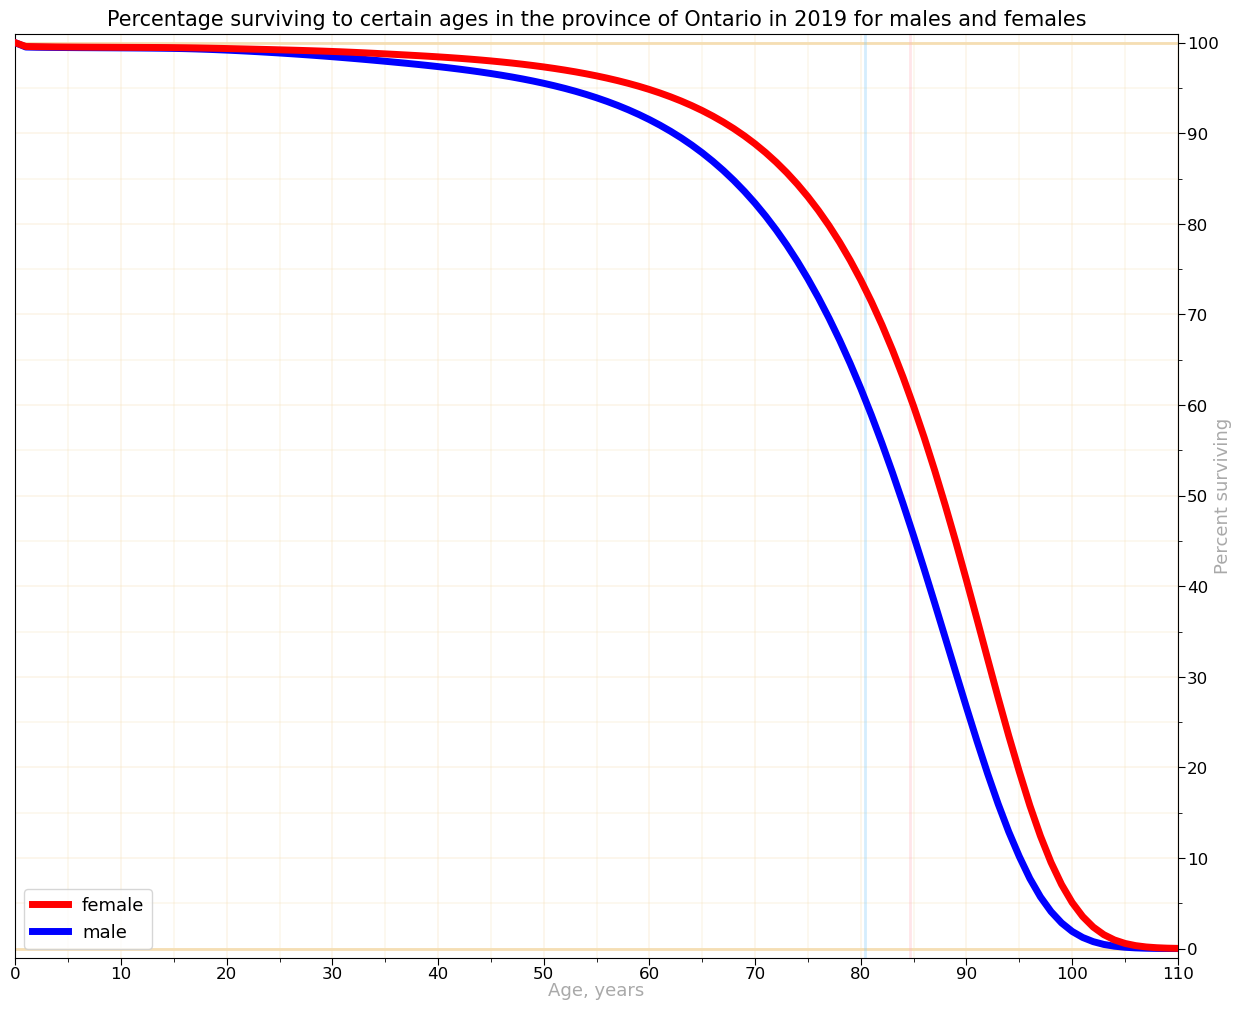

In [27]:
# chart for the province of Ontario

le_male   = 80.38 if YEAR_SELECTED==2019 else 80.68 if YEAR_SELECTED==2024 else None
le_female = 84.67 if YEAR_SELECTED==2019 else 84.99 if YEAR_SELECTED==2024 else None

if REGION_1 == 'Ontario':
    create_chart(df.T.loc[['females_r1', 'males_r1']] \
                   .rename(index={'females_r1': 'females', 'males_r1': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f"Percentage surviving to certain ages in the province of Ontario in {YEAR_SELECTED} for males and females",
                 title_ru=f"Процент выживших к определённому возрасту в провинции Онтарио в {YEAR_SELECTED} для мужчин и женщин",
                 le_male=le_male, le_female=le_female,
                 file_name='Percentage Surviving to Certain Ages in Ontario' + f" in {YEAR_SELECTED}")

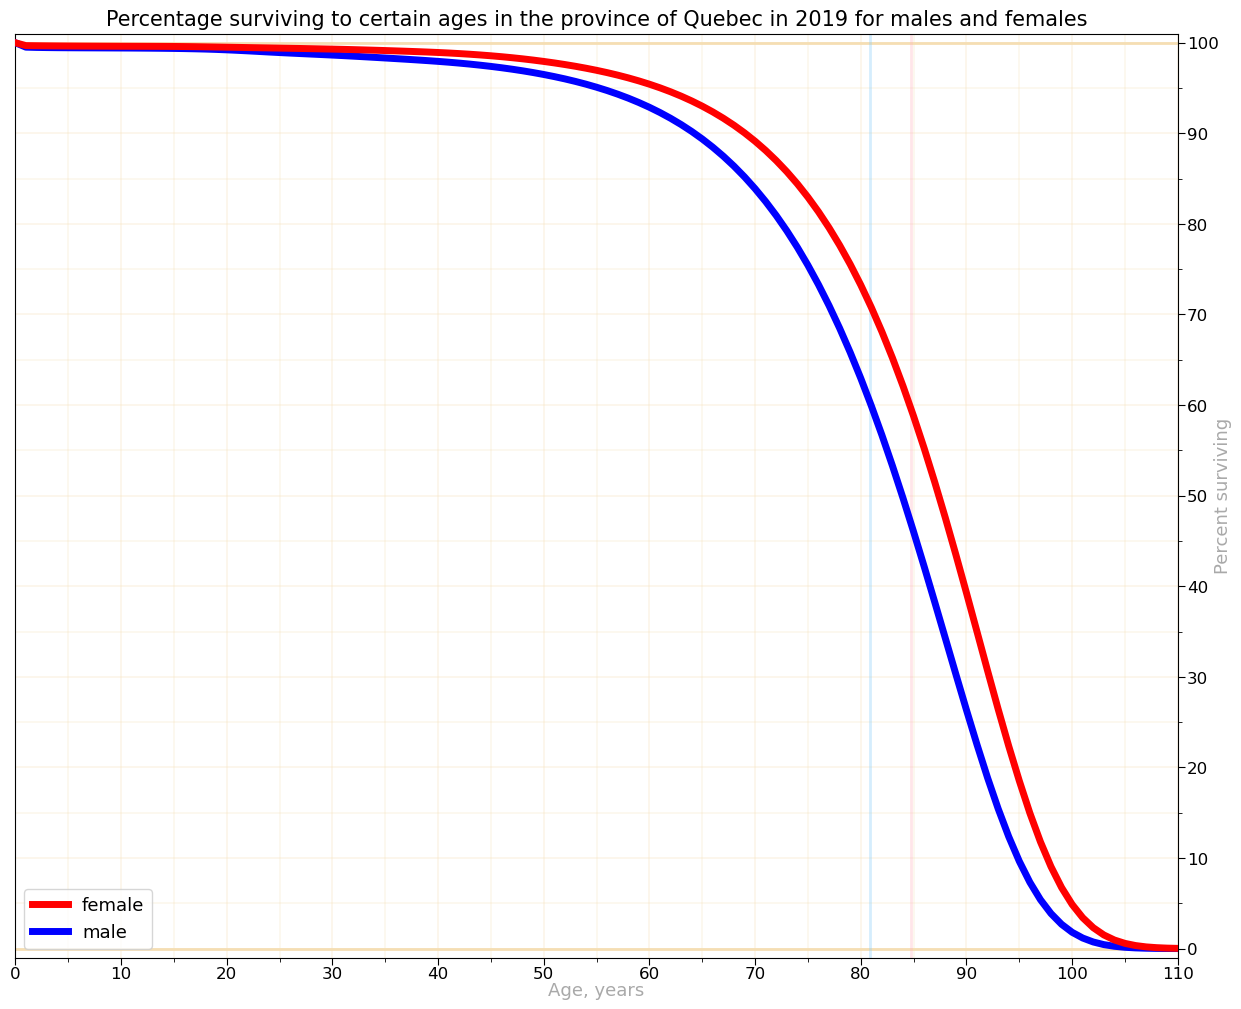

In [28]:
# chart for the province of Quebec

le_male   = 80.92 if YEAR_SELECTED==2019 else 80.90 if YEAR_SELECTED==2024 else None
le_female = 84.71 if YEAR_SELECTED==2019 else 84.39 if YEAR_SELECTED==2024 else None

if REGION_2 == 'Quebec':
    create_chart(df.T.loc[['females_r2', 'males_r2']] \
                   .rename(index={'females_r2': 'females', 'males_r2': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f"Percentage surviving to certain ages in the province of Quebec in {YEAR_SELECTED} for males and females",
                 title_ru=f"Процент выживших к определённому возрасту в провинции Квебек в {YEAR_SELECTED} для мужчин и женщин",
                 le_male=le_male, le_female=le_female,
                 file_name='Percentage Surviving to Certain Ages in Quebec' + f" in {YEAR_SELECTED}")

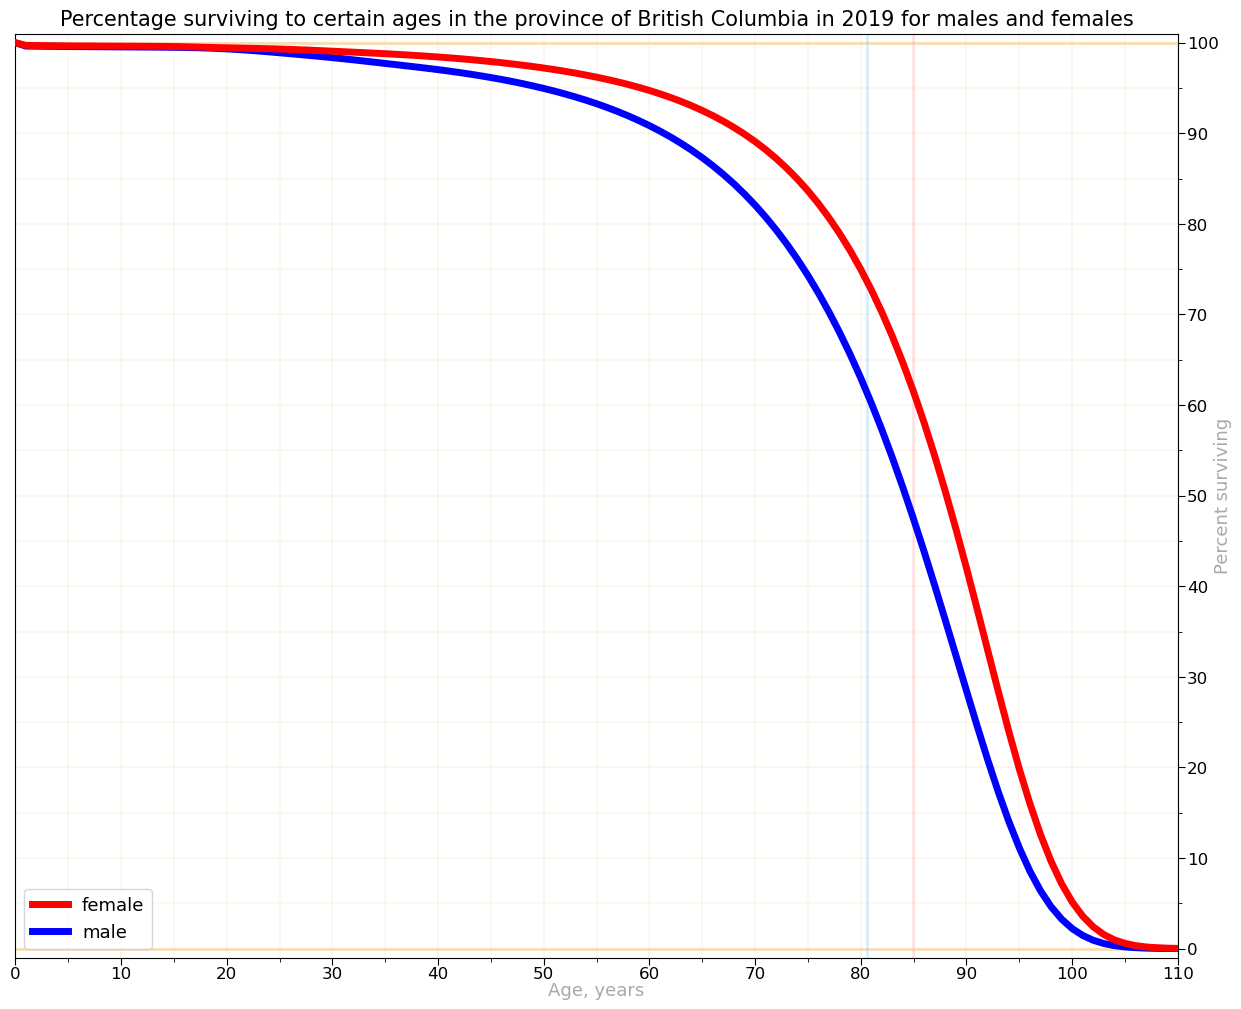

In [29]:
# chart for the province of British Columbia

le_male   = 80.55 if YEAR_SELECTED==2019 else 80.16 if YEAR_SELECTED==2024 else None
le_female = 84.96 if YEAR_SELECTED==2019 else 85.07 if YEAR_SELECTED==2024 else None

if REGION_3 == 'British Columbia':
    create_chart(df.T.loc[['females_r3', 'males_r3']] \
                   .rename(index={'females_r3': 'females', 'males_r3': 'males'}) / 1000,
                 dd_display=dd_display, ncol=1, lang=LANG,
                 title_en=f"Percentage surviving to certain ages in the province of British Columbia in {YEAR_SELECTED} for males and females",
                 title_ru=f"Процент выживших к определённому возрасту в провинции Британская Колумбия в {YEAR_SELECTED} для мужчин и женщин",
                 le_male=le_male, le_female=le_female,
                 file_name='Percentage Surviving to Certain Ages in British Columbia' + f" in {YEAR_SELECTED}")